This notebook is created to apply the implemented Kalman Filters to the VOXL UAV dataset collected at Taltech.

In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report
from utils import normalize_angles, lla_to_enu

from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm

from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/UAV")
dataset_root_dir = os.path.join(root_path, "data")
uav_data_path = os.path.join(dataset_root_dir, "UAV/v2/2024-05-24-log0001.csv")
df = pd.read_csv(uav_data_path)

In [3]:
df.columns

Index(['timestamp', 'stereo image left', 'stereo image right', 'timestamp.1',
       'lat', 'lon', 'alt', 'voxl_imu0_timestamp', 'voxl_imu0_AX(m/s2)',
       'voxl_imu0_AY(m/s2)', 'voxl_imu0_AZ(m/s2)', 'voxl_imu0_GX(rad/s)',
       'voxl_imu0_GY(rad/s)', 'voxl_imu0_GZ(rad/s)', 'voxl_imu1_timestamp',
       'voxl_imu1_AX(m/s2)', 'voxl_imu1_AY(m/s2)', 'voxl_imu1_AZ(m/s2)',
       'voxl_imu1_GX(rad/s)', 'voxl_imu1_GY(rad/s)', 'voxl_imu1_GZ(rad/s)'],
      dtype='object')

In [4]:
required_columns = ['timestamp', 'lat', 'lon', 'alt', 'voxl_imu0_AX(m/s2)',
       'voxl_imu0_AY(m/s2)', 'voxl_imu0_AZ(m/s2)', 'voxl_imu0_GX(rad/s)',
       'voxl_imu0_GY(rad/s)', 'voxl_imu0_GZ(rad/s)',
       'voxl_imu1_AX(m/s2)', 'voxl_imu1_AY(m/s2)', 'voxl_imu1_AZ(m/s2)',
       'voxl_imu1_GX(rad/s)', 'voxl_imu1_GY(rad/s)', 'voxl_imu1_GZ(rad/s)']

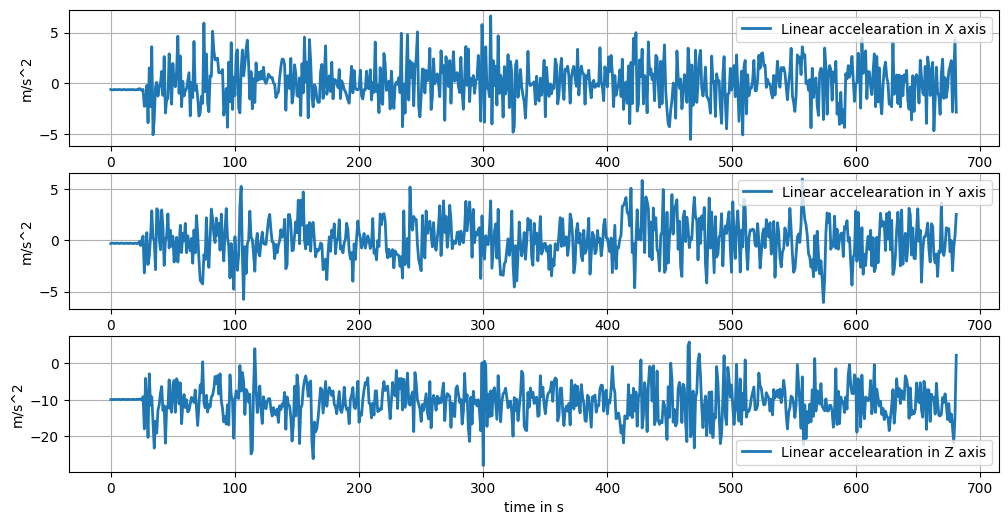

In [5]:
def plot_imu(df, is_acceleration, prefix=""):
    columns = ["GX(rad/s)", "GY(rad/s)", "GZ(rad/s)"]
    labels = ['Angular velocity in X axis', 'Angular velocity in Y axis', 'Angular velocity in Z axis']
    yAxis = "rad/s"
    if is_acceleration:
        columns = ["AX(m/s2)", "AY(m/s2)", "AZ(m/s2)"]
        labels = ['Linear accelearation in X axis', 'Linear accelearation in Y axis', 'Linear accelearation in Z axis']
        yAxis = "m/s^2"
    fig, axs = plt.subplots(3, 1, figsize=(12, 6))
    x = [i for i in range(0, len(df))]
    for i in range(3):
        y = df[prefix + columns[i]]
        axs[i].plot(x, y, lw=2, label=labels[i])
        axs[i].set_xlabel('time in s')
        axs[i].set_ylabel(yAxis)
        axs[i].legend()
        axs[i].grid()

plot_imu(df=df, is_acceleration=True, prefix="voxl_imu0_")

In [6]:
gps = []
imu0 = []
imu1 = []
time = []
for row in df[required_columns].values:
    gps.append(
        row[1:4]
    )
    imu0.append(
        row[4:10]
    )
    imu1.append(
        row[10:]
    )
    time.append(row[0])
    
gps = np.array(gps).T
origin = gps[:, 0]
gps = lla_to_enu(gps, origin).T # convert gps coord to xyz global coord
imu0 = np.array(imu0)
imu1 = np.array(imu1)
time = np.array(time)
time_delta = np.concatenate([
    np.array([1e-10]), #avoiding dividing by zero
    np.diff(time / 1e9)
])

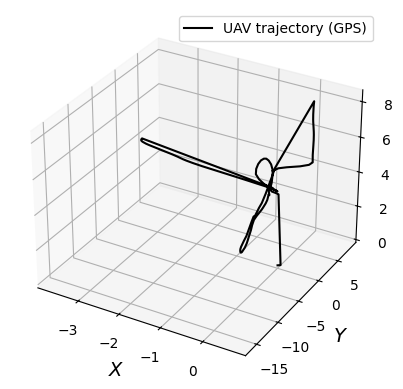

In [7]:
x, y, z = gps.T

ax = plt.figure().add_subplot(projection='3d')

ax.plot(x, y, z, label='UAV trajectory (GPS)', color='black')
ax.legend()

ax.set_xlabel('$X$', fontsize=14)
ax.set_ylabel('$Y$', fontsize=14)
ax.set_zlabel('$\gamma$', fontsize=14)
plt.show()

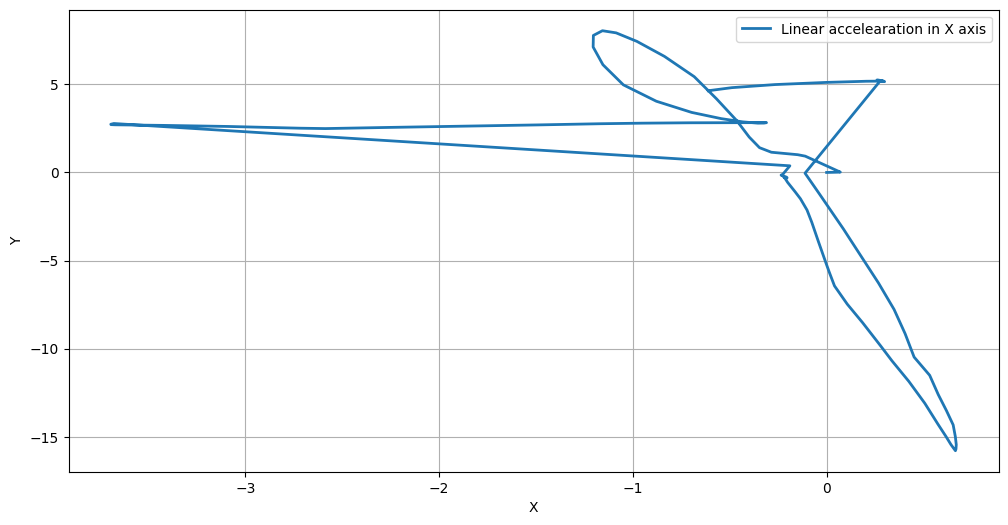

In [8]:
x, y, z = gps.T
fig, axs = plt.subplots(1, 1, figsize=(12, 6))
axs.plot(x, y, lw=2, label='Linear accelearation in X axis')
axs.set_xlabel('X')
axs.set_ylabel('Y')
axs.legend()
axs.grid()


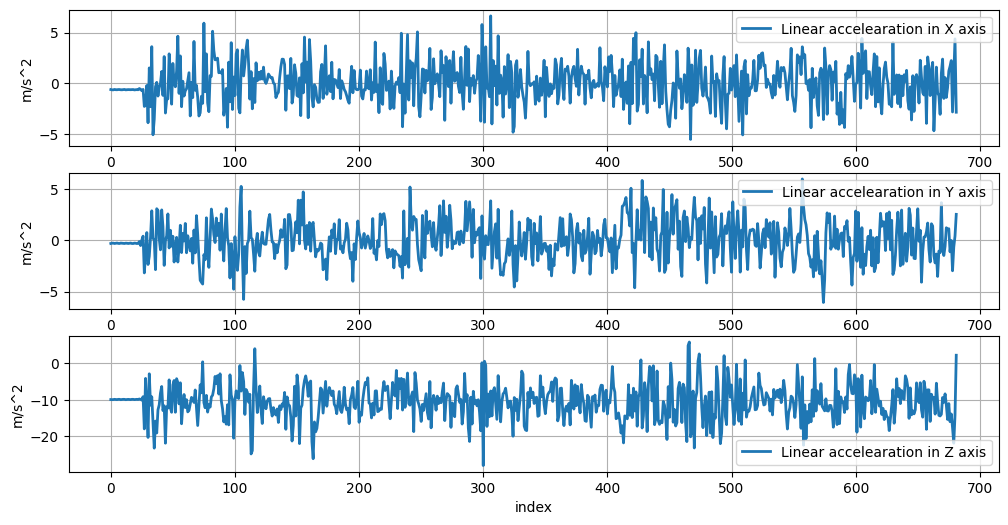

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(12, 6))
x = [i for i in range(len(imu0))]
y = imu0[:, 0]
axs[0].plot(x, y, lw=2, label='Linear accelearation in X axis')
axs[0].set_xlabel('index')
axs[0].set_ylabel('m/s^2')
axs[0].legend()
axs[0].grid()

y = imu0[:, 1]
axs[1].plot(x, y, lw=2, label='Linear accelearation in Y axis')
axs[1].set_xlabel('index')
axs[1].set_ylabel('m/s^2')
axs[1].legend()
axs[1].grid()

y = imu0[:, 2]
axs[2].plot(x, y, lw=2, label='Linear accelearation in Z axis')
axs[2].set_xlabel('index')
axs[2].set_ylabel('m/s^2')
axs[2].legend()
axs[2].grid()

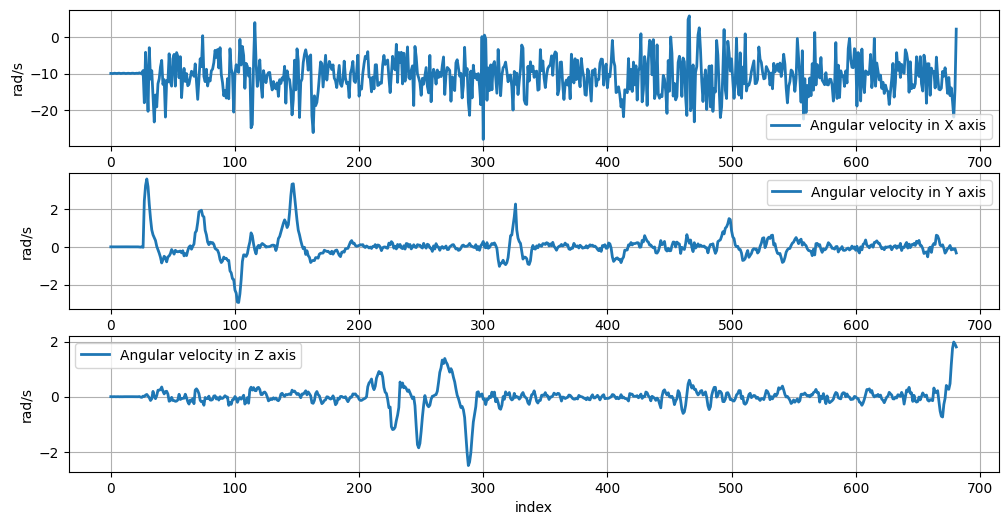

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(12, 6))
x = [i for i in range(len(imu0))]
y = imu0[:, 2]
axs[0].plot(x, y, lw=2, label='Angular velocity in X axis')
axs[0].set_xlabel('index')
axs[0].set_ylabel('rad/s')
axs[0].legend()
axs[0].grid()

y = imu0[:, 3]
axs[1].plot(x, y, lw=2, label='Angular velocity in Y axis')
axs[1].set_xlabel('index')
axs[1].set_ylabel('rad/s')
axs[1].legend()
axs[1].grid()

y = imu0[:, 4]
axs[2].plot(x, y, lw=2, label='Angular velocity in Z axis')
axs[2].set_xlabel('index')
axs[2].set_ylabel('rad/s')
axs[2].legend()
axs[2].grid()

In [11]:
# state vector
x = np.array([
    [gps[0, 0]], #px
    [gps[0, 1]], #py
    [gps[0, 2]], #pz
    [0], #vx
    [0], #vy
    [0], #vz
    [1], #q0
    [0], #q1
    [0], #q2
    [0]  #q3
])
# state error covariance matrix
P = np.eye(10) * 0.1
# process noise vector
# q = np.array([0.01, 0.01, 0.01, 0.0035,0.0035, 0.0035])
q = np.array([0.01, 0.01, 0.01, 0.0, 0.0, 0.0])
# state transform matrix (state space -> measurement space)
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,]
])
# measurement noise vector
r_vo = np.array([0.01, 0.01, 0.01])
r_gps = np.array([0.01, 0.01, 0.01])

N = len(gps)

ekf0 = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps
)
ekf1 = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps
)

In [12]:
t_last = time[0] / 1e9

mu0 = [ekf0.x.copy()[0:3, 0]]
mu1 = [ekf1.x.copy()[0:3, 0]]

for t_idx in tqdm(range(1, N)):
    t = time[t_idx] / 1e9
    dt = t - t_last
    
    u0 = np.array(imu0[t_idx])
    u1 = np.array(imu1[t_idx])
    ekf0.predict_setup1_2(u=u0, dt=dt, Q=ekf0.Q)
    ekf1.predict_setup1_2(u=u0, dt=dt, Q=ekf1.Q)

    x_hat0 = ekf0.x.copy()
    x_hat1 = ekf1.x.copy()
    mu0.append(x_hat0[0:3, 0])
    mu1.append(x_hat1[0:3, 0])

    z_gps = np.array(gps[t_idx]).reshape(-1, 1)
    ekf0.update(z=z_gps, R=ekf0.R_gps)
    ekf1.update(z=z_gps, R=ekf1.R_gps)
    
    t_last = t

mu0 = np.array(mu0)
mu1 = np.array(mu1)

print(get_error_report(gps, mu0))
print(get_error_report(gps, mu1))

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 681/681 [00:00<00:00, 2838.84it/s]

{<ErrorEnum.MAE: 1>: 33.855, <ErrorEnum.RMSE: 2>: 533.467, <ErrorEnum.MAX: 3>: 14835.487}
{<ErrorEnum.MAE: 1>: 33.855, <ErrorEnum.RMSE: 2>: 533.467, <ErrorEnum.MAX: 3>: 14835.487}


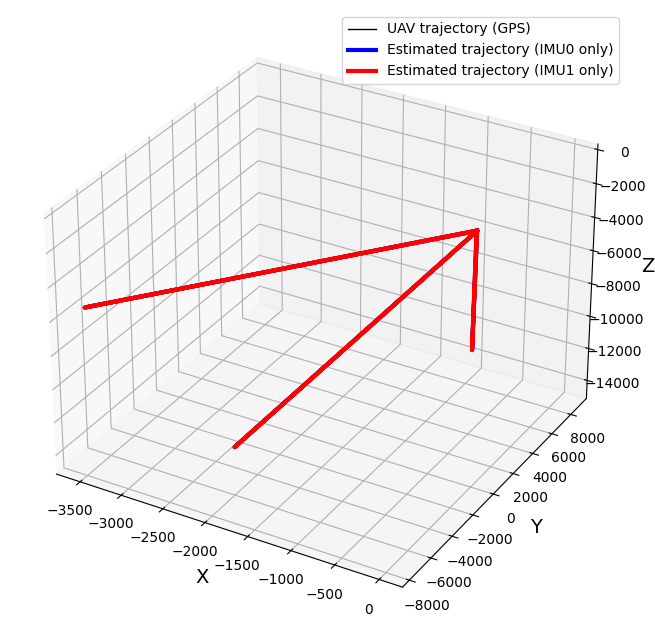

In [13]:
ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')

x, y, z = gps.T
ax.plot(x, y, z, label='UAV trajectory (GPS)', color='black', lw=1)

x, y, z = mu0.T
ax.plot(x, y, z, label='Estimated trajectory (IMU0 only)', color='blue', lw=3)

x, y, z = mu1.T
ax.plot(x, y, z, label='Estimated trajectory (IMU1 only)', color='red', lw=3)
ax.legend()

ax.set_xlabel('X', fontsize=14)
ax.set_ylabel('Y', fontsize=14)
ax.set_zlabel('Z', fontsize=14)
plt.show()

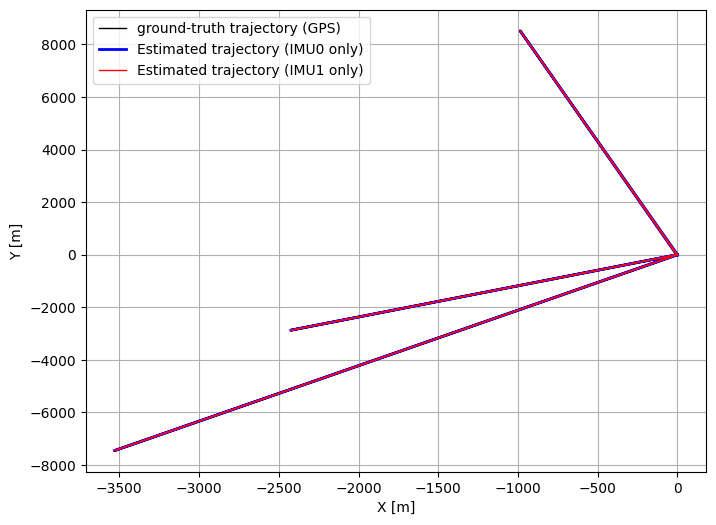

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x, y, _ = gps.T
ax.plot(x, y, label='ground-truth trajectory (GPS)', color='black', lw=1)

x, y, _ = mu0.T
ax.plot(x, y,  label='Estimated trajectory (IMU0 only)', color='blue', lw=2)

x, y, _ = mu1.T
ax.plot(x, y,  label='Estimated trajectory (IMU1 only)', color='red', lw=1)

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')

# ax.set_xlim([-2.7, 0])
# ax.set_ylim([-6.8, 1.5])
ax.legend()
ax.grid()

In [15]:
delta_p = np.linalg.norm(np.concatenate([
    np.zeros((1, 3)),
    np.diff(gps, axis=0)
]), axis=1)

forward_velocity = delta_p / time_delta

In [16]:
delta_p

array([0.00000000e+00, 1.63976577e-02, 6.07373710e-03, 6.07373612e-03,
       6.07373604e-03, 3.44937063e-03, 3.44936760e-03, 3.44936898e-03,
       3.44936855e-03, 3.44937143e-03, 2.73999024e-03, 2.73999215e-03,
       2.73999102e-03, 2.73999089e-03, 2.73999001e-03, 2.73999227e-03,
       2.38970353e-03, 2.38970335e-03, 2.38970280e-03, 2.38970366e-03,
       2.38970291e-03, 2.38970353e-03, 2.80595792e-03, 2.80595665e-03,
       2.80595852e-03, 2.80595773e-03, 2.80595705e-03, 3.91714097e+00,
       7.82671883e-02, 1.50796584e-02, 1.50796582e-02, 1.50796591e-02,
       1.50796585e-02, 1.50796588e-02, 1.50796585e-02, 1.59763490e-02,
       1.59763478e-02, 1.59763476e-02, 1.59763490e-02, 1.59763484e-02,
       1.59763490e-02, 3.31829421e-02, 3.31829400e-02, 3.31829411e-02,
       6.65916140e-02, 6.65916156e-02, 6.65916140e-02, 6.65916156e-02,
       1.00678709e-01, 1.00678710e-01, 1.00678710e-01, 1.00678710e-01,
       1.00678710e-01, 1.00678710e-01, 1.53880537e-01, 1.53880536e-01,
      

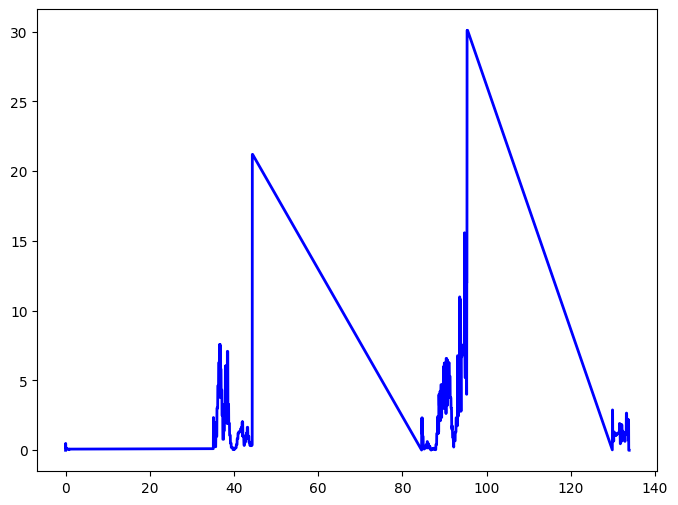

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
x = np.cumsum(time_delta)
ax.plot(x, forward_velocity,  label='Estimated trajectory (IMU0 only)', color='blue', lw=2)

In [18]:
def get_rotation_matrix(q):
    q0, q1, q2, q3 = q[:, 0]
    # https://ahrs.readthedocs.io/en/latest/filters/ekf.html
    # https://www.iri.upc.edu/people/jsola/JoanSola/objectes/notes/kinematics.pdf
    return np.array([
        [q0**2 + q1**2 - q2**2 - q3**2, 2*(q1*q2 - q0*q3), 2*(q1*q3 + q0*q2)],
        [2*(q1*q2 + q0*q3), q0**2 - q1**2 + q2**2 - q3**2, 2*(q2*q3 - q0*q1)],
        [2*(q1*q3 - q0*q2), 2*(q2*q3 + q0*q1), q0**2 - q1**2 - q2**2 + q3**2]
    ])
def get_quaternion_update_matrix(w):
    wx, wy, wz = w[:, 0]
    # https://ahrs.readthedocs.io/en/latest/filters/ekf.html
    # https://www.iri.upc.edu/people/jsola/JoanSola/objectes/notes/kinematics.pdf
    return np.array([ # w, x, y, z
        [0, -wx, -wy, -wz],
        [wx, 0, -wz, wy],
        [wy, wz, 0, -wx],
        [wz, -wy, wx, 0]
    ])
def get_quaternion(u, q_prev):
    return madgwick.updateIMU(q_prev.flatten(), gyr=u[3:], acc=u[:3])
    
def get_euler_angle_from_quaternion(q):
    w, x, y, z = q
    roll = np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2))
    pitch = -np.pi/2 + 2*np.arctan2(np.sqrt(1 + 2*(w*y - x*z)), np.sqrt(1-2*(w*y - x*z)))
    yaw = np.arctan2(2*(w*z + x*y), 1-2*(y**2 + z**2))
    
    return np.array([roll, pitch, yaw])

In [19]:
for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    # without noise
    ax, ay, az = data.IMU_outputs[t_idx, :3]
    wx, wy, wz = data.IMU_outputs[t_idx, 3:]
    
    u = np.array([
        ax,
        ay,
        az,
        wx,
        wy,
        wz
    ])
    a = u[:3]
    a = a.reshape(-1, 1)
    w = u[3:]
    w = w.reshape(-1, 1)
    
    Q1[t_idx] = get_quaternion(u, q_prev=Q1[t_idx -1])

    Omega = get_quaternion_update_matrix(w)
    norm_w = compute_norm_w(w)
    A = np.cos(norm_w*dt/2) * np.eye(4)
    B = (1/norm_w)*np.sin(norm_w*dt/2) * Omega

    q_k = np.array(A + B) @ Q2[t_idx-1]
    q_k /= np.linalg.norm(q_k)
    Q2[t_idx] = q_k

    R1 = get_rotation_matrix(Q1[t_idx - 1].reshape(-1, 1))
    R2 = get_rotation_matrix(Q2[t_idx - 1].reshape(-1, 1))
    
    v_1 = v1[t_idx-1] + (R1 @ a - g) * dt
    v_2 = v2[t_idx-1] + (R2 @ a - g) * dt

    v1.append(v_1)
    v2.append(v_2)
    
    t_last = t


NameError: name 'data' is not defined